## setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import yfinance as yf
import cvxpy as cp

np.random.seed(42)

## Downloading Data

**IT Sector:**  TCS, INFY, WIPRO, HCLTECH

**Banking / Financial Sector:** HDFCBANK, ICICIBANK, SBIN

**Energy / Power Sector:**  RELIANCE, ONGC, NTPC

In [2]:
tickers = [
    "INFY.NS","TCS.NS","WIPRO.NS","HCLTECH.NS",
    "HDFCBANK.NS","ICICIBANK.NS","SBIN.NS",
    "RELIANCE.NS","ONGC.NS","NTPC.NS"
]

In [3]:
start = "2006-01-01"   
end   =  "2026-01-01" 

In [4]:
data = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False,
    group_by="ticker",
    threads=True
)

[*********************100%***********************]  10 of 10 completed


In [5]:
data = data.xs("Adj Close", axis=1, level=1) # consider only adj close.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4936 entries, 2006-01-02 to 2025-12-31
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HDFCBANK.NS   4935 non-null   float64
 1   NTPC.NS       4935 non-null   float64
 2   WIPRO.NS      4935 non-null   float64
 3   ICICIBANK.NS  4935 non-null   float64
 4   ONGC.NS       4935 non-null   float64
 5   TCS.NS        4935 non-null   float64
 6   SBIN.NS       4935 non-null   float64
 7   HCLTECH.NS    4936 non-null   float64
 8   INFY.NS       4935 non-null   float64
 9   RELIANCE.NS   4935 non-null   float64
dtypes: float64(10)
memory usage: 424.2 KB


In [7]:
data.isna().sum()


Ticker
HDFCBANK.NS     1
NTPC.NS         1
WIPRO.NS        1
ICICIBANK.NS    1
ONGC.NS         1
TCS.NS          1
SBIN.NS         1
HCLTECH.NS      0
INFY.NS         1
RELIANCE.NS     1
dtype: int64

In [8]:
data=data.ffill()

In [9]:
data.isna().sum()

Ticker
HDFCBANK.NS     0
NTPC.NS         0
WIPRO.NS        0
ICICIBANK.NS    0
ONGC.NS         0
TCS.NS          0
SBIN.NS         0
HCLTECH.NS      0
INFY.NS         0
RELIANCE.NS     0
dtype: int64

In [10]:
data.head()

Ticker,HDFCBANK.NS,NTPC.NS,WIPRO.NS,ICICIBANK.NS,ONGC.NS,TCS.NS,SBIN.NS,HCLTECH.NS,INFY.NS,RELIANCE.NS
Date,,,,,,,,,,
2006-01-02,30.568829,49.691544,41.777660,85.158363,57.585018,141.637802,66.232552,40.710861,119.656548,55.198135
2006-01-03,30.562407,50.183987,42.800159,86.513474,58.510410,145.464981,66.755882,41.526817,120.762978,56.559879
2006-01-04,31.365776,51.527008,43.533096,87.540520,57.304718,146.295898,67.184067,41.726265,122.706833,57.165428
2006-01-05,31.684990,51.056961,42.895172,86.235321,57.024460,145.394485,68.896774,42.516518,122.690826,56.664387
2006-01-06,32.946815,51.146488,42.773006,85.607704,58.138329,143.148560,68.812607,44.299515,122.622505,56.602905


#### 1. Returns
Using the Adjusted closing prices, calculate the log returns of the stock.
The **log return** on day $t$, denoted as $r_t$, is defined as the natural logarithm of the ratio of the price at time $t$  ($P_t$) to the price at time $t-1$  ($P_{t-1}$):
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$




Log returns are time-additive and statistically more stable (closer to normal), which makes mean–variance modeling and optimization mathematically consistent and numerically robust compared to simple (normal) returns.

In [11]:
log_returns = np.log(data/ data.shift(1)).dropna()

print(log_returns.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4935 entries, 2006-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HDFCBANK.NS   4935 non-null   float64
 1   NTPC.NS       4935 non-null   float64
 2   WIPRO.NS      4935 non-null   float64
 3   ICICIBANK.NS  4935 non-null   float64
 4   ONGC.NS       4935 non-null   float64
 5   TCS.NS        4935 non-null   float64
 6   SBIN.NS       4935 non-null   float64
 7   HCLTECH.NS    4935 non-null   float64
 8   INFY.NS       4935 non-null   float64
 9   RELIANCE.NS   4935 non-null   float64
dtypes: float64(10)
memory usage: 424.1 KB
None


In [12]:
log_returns.head()

Ticker,HDFCBANK.NS,NTPC.NS,WIPRO.NS,ICICIBANK.NS,ONGC.NS,TCS.NS,SBIN.NS,HCLTECH.NS,INFY.NS,RELIANCE.NS
Date,,,,,,,,,,
2006-01-03,-0.000210,0.009861,0.024180,0.015788,0.015942,0.026662,0.007870,0.019845,0.009204,0.024371
2006-01-04,0.025947,0.026410,0.016980,0.011802,-0.020822,0.005696,0.006394,0.004791,0.015968,0.010649
2006-01-05,0.010126,-0.009164,-0.014762,-0.015022,-0.004903,-0.006181,0.025173,0.018762,-0.000130,-0.008803
2006-01-06,0.039052,0.001752,-0.002852,-0.007305,0.019345,-0.015568,-0.001222,0.041081,-0.000557,-0.001086
2006-01-09,-0.005346,0.000000,-0.025171,-0.015025,0.013909,-0.009804,-0.014140,-0.000853,-0.005699,-0.011525


### Annualize Mean Return & Covariance

####  Expected Returns
Using the returns, calculate the annual expected returns($\mu$) of the stock.
The annual average returns ($\mu$) is given by the average daily return times the number of days stock market is open in a year. 
$$\mu = \frac{1}{n} \sum_{i=1}^{n} r_i * 252 \text{,  exchange is open for 252 days in a year}$$


####  Covariance Matrix
Using the log returns, calculate the covariance matrix(volatility, $\Sigma$) of the stock.
The covariance matrix ($\Sigma$) is given by the covariance of the daily returns times the number of days stock market is open in a year.
$$\Sigma = \frac{1}{n} \sum_{i=1}^{n} r_i * 252 \text{, exchange is open for 252 days in a year}$$


In [13]:
mu = log_returns.mean() * 252
Sigma = log_returns.cov() * 252


We convert to NumPy arrays because optimization solvers (like OSQP) and matrix operations run faster and expect numerical arrays, not pandas objects.

In [14]:


mu = mu.values
Sigma = Sigma.values
n = len(mu)


#### Monte Carlo Portfolio Simulation

In [15]:
import numpy as np

N = 50000          # number of random portfolios
n = len(mu)        # number of assets

# Random weights that sum to 1
weights_mc = np.random.dirichlet(np.ones(n), N)

# Portfolio expected returns
portfolio_returns = weights_mc @ mu

# Portfolio risks (volatility)
portfolio_risks = np.sqrt(
    np.einsum("ij,jk,ik->i", weights_mc, Sigma, weights_mc)
)


### Efficient Frontier Visualization (Monte Carlo)

In [16]:
# Sort portfolios by increasing risk
sorted_idx = np.argsort(portfolio_risks)

sorted_risks   = portfolio_risks[sorted_idx]
sorted_returns = portfolio_returns[sorted_idx]


In [17]:
# Efficient frontier = upper envelope
efficient_returns = np.maximum.accumulate(sorted_returns)
efficient_risks   = sorted_risks


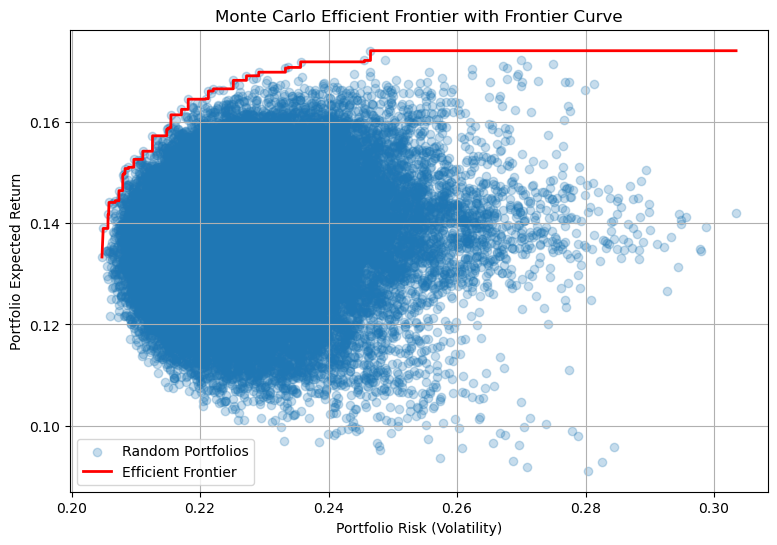

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

# Scatter of all portfolios
plt.scatter(portfolio_risks, portfolio_returns, alpha=0.25, label="Random Portfolios")

# Efficient frontier curve
plt.plot(efficient_risks, efficient_returns, 'r', linewidth=2, label="Efficient Frontier")

plt.xlabel("Portfolio Risk (Volatility)")
plt.ylabel("Portfolio Expected Return")
plt.title("Monte Carlo Efficient Frontier with Frontier Curve")
plt.legend()
plt.grid(True)
plt.show()


## Define 3 Risk Levels

low_risk  = 20th percentile  → conservative portfolios (low volatility)


mid_risk  = 50th percentile  → medium-risk portfolios (typical volatility)


high_risk = 80th percentile  → aggressive portfolios (high volatility)


**“Among all simulated portfolios whose risk is ≤ a given risk level, which portfolio gives the maximum return?”**

In [19]:
low_risk  = np.percentile(portfolio_risks, 20)
mid_risk  = np.percentile(portfolio_risks, 50)
high_risk = np.percentile(portfolio_risks, 80)

print("Low Risk Level :", low_risk)
print("Mid Risk Level :", mid_risk)
print("High Risk Level:", high_risk)


Low Risk Level : 0.21827459295532306
Mid Risk Level : 0.2255137020271998
High Risk Level: 0.2350365025121249


### Find Best Portfolio Under Each Risk

In [20]:
def best_portfolio(target_risk):
    mask = portfolio_risks <= target_risk
    idx = np.argmax(portfolio_returns[mask])

    best_weights = weights_mc[mask][idx]
    best_return  = portfolio_returns[mask][idx] * 100   # convert to %
    best_risk    = portfolio_risks[mask][idx] * 100     # optional: also %

    return best_weights, best_return, best_risk


Extract Result

In [21]:
w_low,  r_low,  risk_low  = best_portfolio(low_risk)
w_mid,  r_mid,  risk_mid  = best_portfolio(mid_risk)
w_high, r_high, risk_high = best_portfolio(high_risk)


## Convex Optimization using OSQP

##### 2. Operator Splitting Quadratic Program solver(OSQP) 
Two-step iterative process using ADMM (Alternating Direction Method of Multipliers):

1. **Unconstrained QP Step:** Minimize quadratic objective ignoring constraints
$$w^{k+1} = \arg\min_w \frac{1}{2}w^T P w + q^T w + \frac{\rho}{2}\|w - z^k + u^k\|_2^2$$

2. **Projection Step:** Project onto feasible set (simplex + non-negativity)
$$z^{k+1} = \Pi_{\mathcal{C}}(w^{k+1} + u^k)$$

Keeps alternating between these two until convergence.

# Geometrically:

               ##  How OSQP Works Geometrically (Iteration View)

###  Step 1 -- Free Movement (Ignore Constraints Temporarily)
OSQP moves in the direction where the objective surface slopes downward fastest, like a ball rolling downhill without caring about walls. This gives a tentative position that may violate constraints.  
**Geometric intuition:** *“Where would I go if there were no walls?”*

### Step 2 -- Projection Back into Feasible Region
OSQP detects that the point crossed the boundary and projects it back into the feasible region, similar to hitting a wall and sliding back inside a box.  
**Geometric intuition:** *Find the closest point that satisfies all constraints.*

###  Step 3 -- Memory Correction (Balance the Two Forces)
OSQP remembers how much it wanted to move outside and how strongly it was pushed back. In the next iteration, it adjusts its movement to reduce oscillation and zig-zag behavior, helping the solution converge smoothly to the optimal point.


In [22]:
!pip install osqp scipy


### OSQP Solver Function

In [23]:
import osqp
from scipy import sparse

def solve_osqp(target_risk):

    P = sparse.csc_matrix(Sigma)
    q = -mu

    # Constraints:
    # 1) sum(w) = 1
    # 2) w >= 0
    # 3) variance <= target_risk^2

    A = sparse.vstack([
        np.ones((1,n)),
        np.eye(n),
        Sigma
    ]).tocsc()

    l = np.hstack([1, np.zeros(n), -np.inf*np.ones(n)])
    u = np.hstack([1, np.inf*np.ones(n), target_risk**2*np.ones(n)])

    solver = osqp.OSQP()
    solver.setup(P, q, A, l, u, verbose=False)
    result = solver.solve()

    return result.x


In [24]:
w_osqp_low  = solve_osqp(low_risk)
w_osqp_mid  = solve_osqp(mid_risk)
w_osqp_high = solve_osqp(high_risk)


In [25]:


stocks = [t.replace(".NS","") for t in tickers]

df_compare = pd.DataFrame({
    "Stock": stocks,
    "MC Low":  w_low,
    "MC Mid":  w_mid,
    "MC High": w_high,
    "OSQP Low":  w_osqp_low,
    "OSQP Mid":  w_osqp_mid,
    "OSQP High": w_osqp_high
})

print(df_compare)


       Stock    MC Low    MC Mid   MC High  OSQP Low  OSQP Mid  OSQP High
0       INFY  0.373669  0.473016  0.360136  0.294953  0.399472   0.488504
1        TCS  0.047720  0.021907  0.008261  0.160591  0.000252   0.000039
2      WIPRO  0.032147  0.006794  0.043484 -0.000017  0.000061   0.000012
3    HCLTECH  0.012984  0.052824  0.030767  0.000426 -0.001058  -0.001067
4   HDFCBANK  0.006110  0.005722  0.007659 -0.000021  0.000145  -0.000023
5  ICICIBANK  0.179387  0.175766  0.041022  0.228040  0.295465   0.157804
6       SBIN  0.010948  0.007663  0.033788  0.000152 -0.000322  -0.000426
7   RELIANCE  0.178560  0.158597  0.357238  0.068973  0.103903   0.218384
8       ONGC  0.067198  0.052770  0.039414  0.226654  0.114179   0.000049
9       NTPC  0.091277  0.044940  0.078231  0.020247  0.087903   0.136723


OSQP can produce small negative weights due to numerical tolerance and floating-point approximation, even when non-negativity constraints are applied. These values are usually extremely close to zero and can be safely clipped to zero without affecting the portfolio solution.


## Compute Risk & Return from Any Weights (in %)

In [26]:

def portfolio_stats(weights, mu, Sigma):
    """
    weights : array (n,)
    mu      : annual mean returns (decimal)
    Sigma   : annual covariance matrix
    """
    port_return = weights @ mu
    port_risk   = np.sqrt(weights.T @ Sigma @ weights)

    # Convert to percentage for reporting
    return {
        "Return (%)": port_return * 100,
        "Risk (%)":   port_risk * 100
    }


In [27]:
def get_results_for_levels(w_low, w_mid, w_high, mu, Sigma):
    
    stats_low  = portfolio_stats(w_low,  mu, Sigma)
    stats_mid  = portfolio_stats(w_mid,  mu, Sigma)
    stats_high = portfolio_stats(w_high, mu, Sigma)

    return {
        "Low Risk":  {"Weights": w_low,  **stats_low},
        "Mid Risk":  {"Weights": w_mid,  **stats_mid},
        "High Risk": {"Weights": w_high, **stats_high}
    }


## Monte Carlo Results

In [28]:
mc_results = get_results_for_levels(
    w_low, w_mid, w_high, mu, Sigma
)


In [29]:


mc_table = pd.DataFrame({
    "Risk Level": ["Low", "Mid", "High"],
    "Risk (%)": [
        mc_results["Low Risk"]["Risk (%)"],
        mc_results["Mid Risk"]["Risk (%)"],
        mc_results["High Risk"]["Risk (%)"]
    ],
    "Return (%)": [
        mc_results["Low Risk"]["Return (%)"],
        mc_results["Mid Risk"]["Return (%)"],
        mc_results["High Risk"]["Return (%)"]
    ]
}).round(2)

print(" Monte Carlo Results")
print(mc_table)


 Monte Carlo Results
  Risk Level  Risk (%)  Return (%)
0        Low     21.81       16.45
1        Mid     22.52       16.82
2       High     23.37       17.08


## OSQP Results

In [30]:
osqp_results = get_results_for_levels(
    w_osqp_low, w_osqp_mid, w_osqp_high, mu, Sigma
)


In [31]:
osqp_table = pd.DataFrame({
    "Risk Level": ["Low", "Mid", "High"],
    "Risk (%)": [
        osqp_results["Low Risk"]["Risk (%)"],
        osqp_results["Mid Risk"]["Risk (%)"],
        osqp_results["High Risk"]["Risk (%)"]
    ],
    "Return (%)": [
        osqp_results["Low Risk"]["Return (%)"],
        osqp_results["Mid Risk"]["Return (%)"],
        osqp_results["High Risk"]["Return (%)"]
    ]
}).round(2)

print(" OSQP Results")
print(osqp_table)


 OSQP Results
  Risk Level  Risk (%)  Return (%)
0        Low     21.02       15.09
1        Mid     22.14       16.76
2       High     22.92       17.62


# Final Table

In [32]:
comparison_table = pd.DataFrame({
    "Risk Level": ["Low", "Mid", "High"],

    "MC Risk (%)": [
        mc_results["Low Risk"]["Risk (%)"],
        mc_results["Mid Risk"]["Risk (%)"],
        mc_results["High Risk"]["Risk (%)"]
    ],
    "MC Return (%)": [
        mc_results["Low Risk"]["Return (%)"],
        mc_results["Mid Risk"]["Return (%)"],
        mc_results["High Risk"]["Return (%)"]
    ],

    "OSQP Risk (%)": [
        osqp_results["Low Risk"]["Risk (%)"],
        osqp_results["Mid Risk"]["Risk (%)"],
        osqp_results["High Risk"]["Risk (%)"]
    ],
    "OSQP Return (%)": [
        osqp_results["Low Risk"]["Return (%)"],
        osqp_results["Mid Risk"]["Return (%)"],
        osqp_results["High Risk"]["Return (%)"]
    ],
}).round(2)

print(" Monte Carlo vs OSQP Comparison")
print(comparison_table)


 Monte Carlo vs OSQP Comparison
  Risk Level  MC Risk (%)  MC Return (%)  OSQP Risk (%)  OSQP Return (%)
0        Low        21.81          16.45          21.02            15.09
1        Mid        22.52          16.82          22.14            16.76
2       High        23.37          17.08          22.92            17.62
